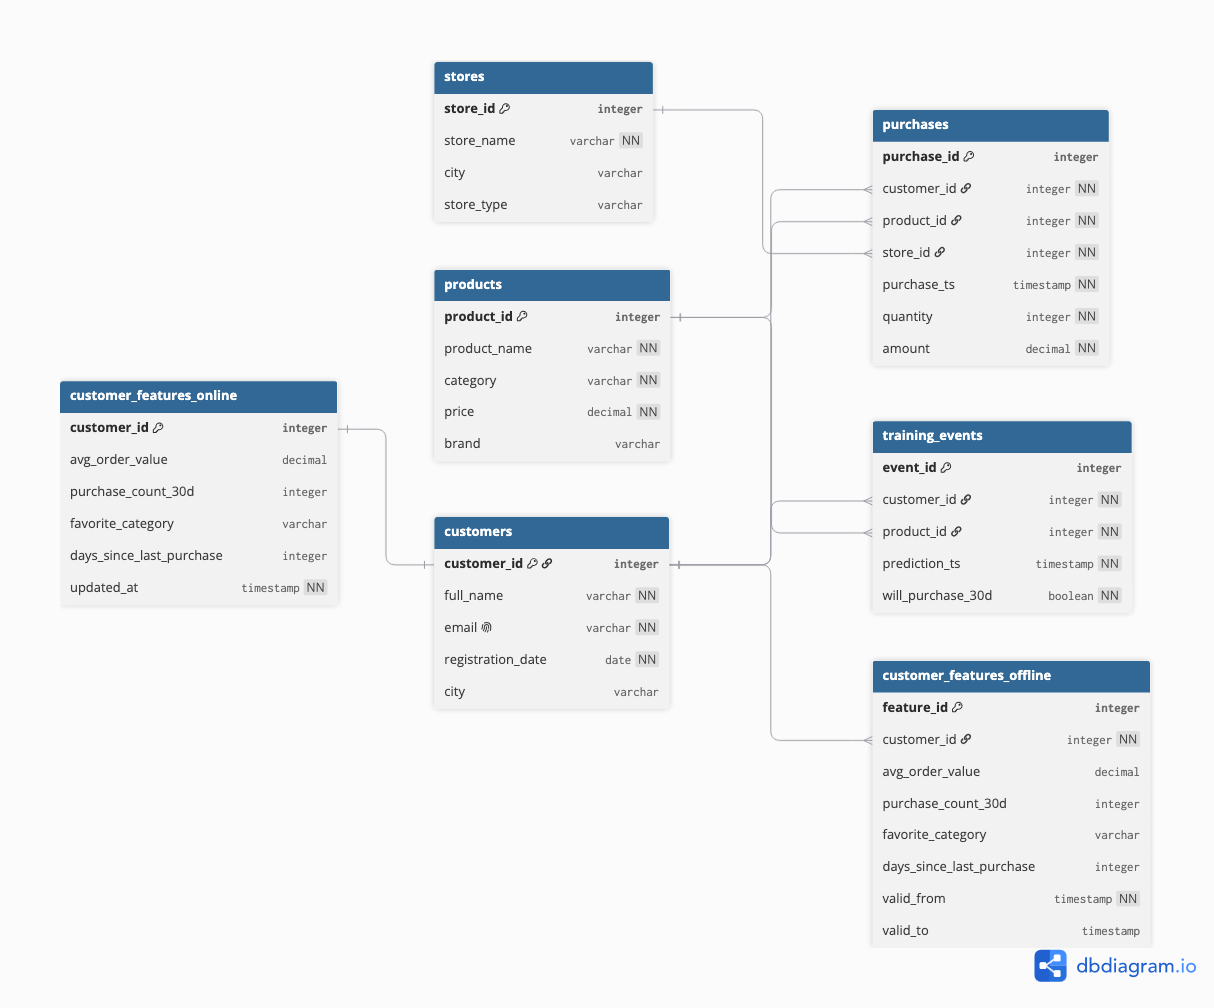

# DDL

In [1]:
import pixeltable_pgserver as pgserver # аналог pgserver
from sqlalchemy import create_engine, text
import pandas as pd


# pgdata буде створена, якщо не існує (батьківська директорія має існувати)
db = pgserver.get_server("./demo", cleanup_mode="delete")

uri = db.get_uri(driver="psycopg")
print("Connection URI:", uri)
print(db.get_postmaster_info().pgdata)
print(db.get_postmaster_info().port)

engine = create_engine(uri, echo=False, future=True)

Connection URI: postgresql+psycopg://postgres:@/postgres?host=/Users/vladyslavratushnyi/Learning/DB_DS/demo
/Users/vladyslavratushnyi/Learning/DB_DS/demo
5432


In [2]:
# кастомна функція для виконання sql
def sql_reader(sql_quary:str, engine, is_file=False)->list:
    try:
        if is_file:
            with open(sql_quary, 'r') as f:
                sql_quary = f.read()

        ddl_statements = [
            query.strip() + ";" 
            for query in sql_quary.split(';') 
            if query.strip()]

        with engine.begin() as conn:
            for stmt in ddl_statements:
                conn.execute(text(stmt))

        return f"{len(ddl_statements)} команд виконано"

    except Exception as e:
        print('Операція не виконана:', e)

In [3]:
# завнтажуємо sql файл
print(sql_reader('hw_ddl.sql', engine=engine, is_file=True))

20 команд виконано


# Нормалізація

**Нормалізація та денормалізація схеми**

**Таблиці hw2_customers, hw2_products, hw2_stores та hw2_purchases перебувають у 3НФ:** кожен неключовий атрибут залежить лише від первинного ключа (customer_id → full_name, email; product_id → product_name, category, price) і немає транзитивних залежностей (наприклад, city не визначає жодного іншого атрибута). Функціональна залежність customer_id → full_name, email, registration_date, city була врахована при виокремленні customers в окрему таблицю замість дублювання цих даних у кожному рядку purchases. Аналогічно декомпозовано products і stores, щоб уникнути update-аномалій (зміна ціни товару не вимагає правок у тисячах рядків покупок).

**customer_features_online навмисно денормалізована:** замість version-history (як в offline) вона зберігає лише останній стан ознак одним рядком на клієнта. Це виправдано read pattern'ом продакшн-inference: lookup за customer_id, потреба в latency < 10мс, і мінімізація JOIN'ів (одна таблиця замість джойну purchases + агрегацій).

**Ризик:** дублювання значень (avg_order_value тощо) між offline і online-версіями може призвести до розсинхронізації, якщо online не оновлюється вчасно.

**Оновлення:** online-таблиця наповнюється періодичним batch/streaming ETL-процесом, який бере останній чинний рядок з hw2_customer_features_offline (де valid_to IS NULL) і виконує UPSERT в hw2_customer_features_online.

# Point-in-Time correctness

### Insert quaryes

In [4]:
com1 = """
SET TIME ZONE 'UTC';

-- 1. БАЗОВІ БІЗНЕС-СУТНОСТІ

INSERT INTO hw2_customers (full_name, email, registration_date, city) VALUES
    ('Олена Ковальчук',  'o.koval@example.com',  '2025-11-10', 'Kyiv'),
    ('Ігор Мельник',     'i.melnyk@example.com', '2025-12-05', 'Lviv'),
    ('Марія Бондар',     'm.bondar@example.com', '2026-01-20', 'Odesa'),
    ('Тарас Шевченко',   't.shevchenko@example.com', '2025-10-01', 'Kharkiv');

INSERT INTO hw2_products (product_name, category, price, brand) VALUES
    ('Wireless Headphones', 'electronics', 89.99, 'SoundMax'),
    ('Running Shoes',       'sportswear',  64.50, 'RunFast'),
    ('Coffee Maker',        'home',        45.00, 'BrewPro');
    """

print(sql_reader(com1, engine=engine))

3 команд виконано


In [5]:
com2 = """
-- customer_id = 1: три послідовні версії
INSERT INTO hw2_customer_features_offline
    (customer_id, avg_order_value, purchase_count_30d, favorite_category, days_since_last_purchase, valid_from, valid_to)
VALUES
    (1, 25.00, 1, 'electronics', 20, '2026-01-01 00:00:00+00', '2026-03-01 00:00:00+00'),  -- v1
    (1, 40.50, 2, 'electronics', 12, '2026-03-01 00:00:00+00', '2026-06-01 00:00:00+00'),  -- v2
    (1, 58.30, 4, 'sportswear',   3, '2026-06-01 00:00:00+00', NULL);                       -- v3 (поточна)

-- customer_id = 2: дві версії
INSERT INTO hw2_customer_features_offline
    (customer_id, avg_order_value, purchase_count_30d, favorite_category, days_since_last_purchase, valid_from, valid_to)
VALUES
    (2, 15.00, 0, 'home',       45, '2026-02-01 00:00:00+00', '2026-05-01 00:00:00+00'),
    (2, 33.20, 3, 'home',        7, '2026-05-01 00:00:00+00', NULL);

-- customer_id = 3: дві версії
INSERT INTO hw2_customer_features_offline
    (customer_id, avg_order_value, purchase_count_30d, favorite_category, days_since_last_purchase, valid_from, valid_to)
VALUES
    (3, 20.00, 1, 'sportswear', 30, '2026-01-15 00:00:00+00', '2026-04-15 00:00:00+00'),
    (3, 47.80, 2, 'electronics', 9, '2026-04-15 00:00:00+00', NULL);

-- customer_id = 4: три послідовні версії
INSERT INTO hw2_customer_features_offline
    (customer_id, avg_order_value, purchase_count_30d, favorite_category, days_since_last_purchase, valid_from, valid_to)
VALUES
    (4, 10.00, 0, 'home',        60, '2026-01-01 00:00:00+00', '2026-03-10 00:00:00+00'),  -- v1
    (4, 22.40, 1, 'home',        18, '2026-03-10 00:00:00+00', '2026-07-10 00:00:00+00'),  -- v2
    (4, 65.90, 5, 'electronics',  2, '2026-07-10 00:00:00+00', NULL);                        -- v3 (поточна)

-- Разом: 3 + 2 + 2 + 3 = 10 рядків
"""

print(sql_reader(com2, engine=engine))

5 команд виконано


In [6]:
com3 = """
-- 3. TRAINING EVENTS
--    Для customer_id=1 три події, кожна потрапляє
--    в різну версію ознак (v1, v2, v3) — демонструє AS-OF join

INSERT INTO hw2_training_events (customer_id, product_id, prediction_ts, will_purchase_30d) VALUES
    (1, 1, '2026-02-15 10:00:00+00', TRUE),   -- потрапляє у v1 (Jan1-Mar1)
    (1, 2, '2026-04-15 10:00:00+00', FALSE),  -- потрапляє у v2 (Mar1-Jun1)
    (1, 2, '2026-08-01 10:00:00+00', TRUE),   -- потрапляє у v3 (Jun1-NULL)
    (2, 3, '2026-03-01 09:00:00+00', FALSE),  -- v1 клієнта 2
    (3, 1, '2026-05-01 12:00:00+00', TRUE),   -- v2 клієнта 3
    (4, 2, '2026-06-01 08:00:00+00', FALSE);  -- v2 клієнта 4
    """

print(sql_reader(com3, engine=engine))

2 команд виконано


### AS-OF Queryes

In [7]:
# Запит 1: AS-OF lookup для ОДНОГО клієнта на конкретний момент
# Які ознаки клієнта 1 були чинні станом на 2026-04-15?

query1 = """
SELECT
    customer_id,
    avg_order_value,
    purchase_count_30d,
    favorite_category,
    days_since_last_purchase,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 1
  AND valid_from <= TIMESTAMPTZ '2026-04-15 00:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2026-04-15 00:00:00+00' OR valid_to IS NULL);
"""

# Очікуваний результат: рівно 1 рядок — версія v2 (40.50, 2, electronics)
pd.read_sql_query(query1, engine.connect())

,customer_id,avg_order_value,purchase_count_30d,favorite_category,days_since_last_purchase,valid_from,valid_to
0,1,40.5,2,electronics,12,2026-03-01 00:00:00+00:00,2026-06-01 00:00:00+00:00


In [8]:
# Запит 2: AS-OF snapshot для УСІХ клієнтів на один момент часу
# Знімок стану ознак усіх клієнтів станом на 2026-05-01

query2 = """
SELECT DISTINCT ON (customer_id)
    customer_id,
    avg_order_value,
    purchase_count_30d,
    favorite_category,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE valid_from <= TIMESTAMPTZ '2026-05-01 00:00:00+00'
  AND (valid_to > TIMESTAMPTZ '2026-05-01 00:00:00+00' OR valid_to IS NULL)
ORDER BY customer_id, valid_from DESC;
"""

# По одному чинному рядку на кожного customer_id, без дублікатів
pd.read_sql_query(query2, engine.connect())

,customer_id,avg_order_value,purchase_count_30d,favorite_category,valid_from,valid_to
0,1,40.5,2,electronics,2026-03-01 00:00:00+00:00,2026-06-01 00:00:00+00:00
1,2,33.2,3,home,2026-05-01 00:00:00+00:00,NaT
2,3,47.8,2,electronics,2026-04-15 00:00:00+00:00,NaT
3,4,22.4,1,home,2026-03-10 00:00:00+00:00,2026-07-10 00:00:00+00:00


In [9]:
# Запит 3: AS-OF JOIN training_events <-> customer_features_offline
# Головний запит: формування коректного тренувального датасету

query3 = """
SELECT
    te.event_id,
    te.customer_id,
    te.product_id,
    te.prediction_ts,
    cfo.avg_order_value,
    cfo.purchase_count_30d,
    cfo.favorite_category,
    cfo.days_since_last_purchase,
    cfo.valid_from  AS feature_valid_from,
    cfo.valid_to    AS feature_valid_to,
    te.will_purchase_30d AS target
FROM hw2_training_events te
JOIN hw2_customer_features_offline cfo
    ON cfo.customer_id = te.customer_id
   AND cfo.valid_from <= te.prediction_ts
   AND (cfo.valid_to > te.prediction_ts OR cfo.valid_to IS NULL)
ORDER BY te.customer_id, te.prediction_ts;
"""

# Кожна training-подія отримує РІВНО ОДНУ версію ознак -
# ту, що була чинна саме в момент prediction_ts
pd.read_sql_query(query3, engine.connect())

,event_id,customer_id,product_id,prediction_ts,avg_order_value,purchase_count_30d,favorite_category,days_since_last_purchase,feature_valid_from,feature_valid_to,target
0,1,1,1,2026-02-15 10:00:00+00:00,25.0,1,electronics,20,2026-01-01 00:00:00+00:00,2026-03-01 00:00:00+00:00,True
1,2,1,2,2026-04-15 10:00:00+00:00,40.5,2,electronics,12,2026-03-01 00:00:00+00:00,2026-06-01 00:00:00+00:00,False
2,3,1,2,2026-08-01 10:00:00+00:00,58.3,4,sportswear,3,2026-06-01 00:00:00+00:00,NaT,True
3,4,2,3,2026-03-01 09:00:00+00:00,15.0,0,home,45,2026-02-01 00:00:00+00:00,2026-05-01 00:00:00+00:00,False
4,5,3,1,2026-05-01 12:00:00+00:00,47.8,2,electronics,9,2026-04-15 00:00:00+00:00,NaT,True
5,6,4,2,2026-06-01 08:00:00+00:00,22.4,1,home,18,2026-03-10 00:00:00+00:00,2026-07-10 00:00:00+00:00,False


In [10]:
# Перевірка перекривних інтервалів (overlapping)
# temporal-версії для одного customer_id

# self-join — знаходить КОНКРЕТНІ пари версій,
# що перекриваються

query4 = """
SELECT
    a.customer_id,
    a.feature_id AS feature_id_a,
    a.valid_from AS valid_from_a,
    a.valid_to   AS valid_to_a,
    b.feature_id AS feature_id_b,
    b.valid_from AS valid_from_b,
    b.valid_to   AS valid_to_b
FROM hw2_customer_features_offline a
JOIN hw2_customer_features_offline b
    ON a.customer_id = b.customer_id
   AND a.feature_id < b.feature_id           -- кожна пара порівнюється один раз
WHERE a.valid_from < COALESCE(b.valid_to, 'infinity'::timestamptz)
  AND b.valid_from < COALESCE(a.valid_to, 'infinity'::timestamptz);
"""

pd.read_sql_query(query4, engine.connect())

,customer_id,feature_id_a,valid_from_a,valid_to_a,feature_id_b,valid_from_b,valid_to_b


Пояснення AS-OF логіки

1. Чому valid_from <= prediction_ts
Ця умова відкидає всі версії ознак, які почали діяти після моменту прогнозу. Модель у продакшені ніколи не бачить версію фічі, що з'явилась пізніше за момент, коли робиться прогноз — тож і в тренувальних даних це має відтворюватись чесно.

2. Чому valid_to > prediction_ts OR valid_to IS NULL
Гарантує, що обрана версія ще не "закрилась" на момент prediction_ts (а IS NULL означає версію, яка досі активна — не має верхньої межі). Без цієї умови можна було б захопити версію, що вже втратила чинність задовго до прогнозу.

3. Чому інтервали напіввідкриті [valid_from, valid_to)
Це виключає граничну неоднозначність: у момент рівно valid_to нова версія вже діє, а стара — ні. Якби інтервал був закритим [valid_from, valid_to], у точці стику двох версій підійшли б одразу дві версії — це і є "перекриття", яке вимога явно забороняє.

4. Що потрапило б із майбутнього без часового фільтра
Простий JOIN ... ON cfo.customer_id = te.customer_id (без умов на час) повернув би усі версії ознак клієнта одразу — включно з тими, що з'явились після prediction_ts. Для customer_id=1 та prediction_ts='2026-02-15' такий JOIN дав би 3 рядки замість 1: версію v1 (правильну) плюс v2 і v3, які на момент прогнозу ще навіть не існували. Це:

Дублікати — один training event розмножується на кілька рядків (по одному на кожну версію ознак), спотворюючи розподіл класів і вагу прикладів;

Data leakage — модель бачить майбутні значення ознак (наприклад, purchase_count_30d, розраховане вже після того, як клієнт зробив покупку, за яку модель мала передбачити ймовірність). Це штучно завищує якість на тесті, а в продакшені модель різко деградує, бо таких "підказок із майбутнього" там просто не буде.

In [ ]:
# engine.dispose()
# db.cleanup()
# print("Сервер зупинено.")

Сервер зупинено.


# Reflection

**Що було найскладнішим:**

Мені як початківцю в роботі з sql було дуже складно розібратися в налаштуваннях point-in-time correctness. По перше у мене зайняло багато часу створення усіх CONSTRAINT часових умов стовпців таблиць. По друге було важко тримати в голові всі ці взаємозвʼзки створених таблиць, можна легко заплутатись.

**Проєктні компроміси:**

Бізнес-сутності (customers, products, stores) та bridge-таблицю purchases я нормалізував до 3НФ — це критично для транзакційної цілісності: ціна товару чи email клієнта зберігаються в одному місці, без аномалій оновлення. hw2_Offline feature store також нормалізований у сенсі відсутності дублювання логіки — версійність через valid_from/valid_to замість перезапису історії. Натомість customer_features_online навмисно денормалізований: один плаский рядок на клієнта без history та без JOIN'ів. Це відповідає сценарію — offline читається рідко, аналітично, batch'ами (де JOIN'и дешеві), а online — часто, з низькою latency, де кожен зайвий JOIN коштує мілісекунд у продакшн-inference.

**Масштабування online-рівня:**

При зростанні кількості користувачів варто перейти на key-value сховище (Redis/DynamoDB) з попередньо матеріалізованими ознаками за entity_id, кешуванням "гарячих" клієнтів, горизонтальним шардингом за customer_id та асинхронним TTL-based оновленням, прийнявши компроміс eventual consistency заради швидкості.

**Ризики еволюції схеми:**

За півроку ймовірні:  
- зміна типів (наприклад, INTEGER→NUMERIC для точнішого підрахунку); 
- зміна purchase_count_30d порахований інакше без зміни назви;
- видалення застарілих колонок і необхідність версіонувати feature-схему, щоб старі моделі продовжували отримувати сумісний набір ознак.